In [1]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Step 2: Upload file
from google.colab import files
uploaded = files.upload()

# Preview
df.head()

Saving UKDiabetes_Audit_dataset.csv to UKDiabetes_Audit_dataset (1).csv


,Section,Table/Figure,Title,Period,Country,Age_years,Breakdown/Measure,Data_Type,Value,Value_Denominator,Value_Numerator
0,Characteristics,Table 1,Adolescents and young adults with type 1 diabe...,2017-21,England,15-25,Total,%,100.0,57060.0,57060.0
1,Characteristics,Table 1,Adolescents and young adults with type 1 diabe...,2017-21,England,15-25,Female,%,44.8,57060.0,25540.0
2,Characteristics,Table 1,Adolescents and young adults with type 1 diabe...,2017-21,England,15-25,Male,%,55.2,57060.0,31520.0
3,Characteristics,Table 2,Adolescents and young adults with type 1 diabe...,2017-21,England,15-25,Total,%,100.0,57060.0,57060.0
4,Characteristics,Table 2,Adolescents and young adults with type 1 diabe...,2017-21,England,15-25,White,%,82.1,57060.0,46850.0


In [6]:
# Clean column names
df.columns = df.columns.str.strip()

# Convert Value column to numeric
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Drop missing values in Value
df = df.dropna(subset=["Value"])

# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Section            1068 non-null   object 
 1   Table/Figure       1068 non-null   object 
 2   Title              1068 non-null   object 
 3   Period             1068 non-null   object 
 4   Country            1068 non-null   object 
 5   Age_years          1068 non-null   object 
 6   Breakdown/Measure  990 non-null    object 
 7   Data_Type          1068 non-null   object 
 8   Value              1068 non-null   float64
 9   Value_Denominator  574 non-null    float64
 10  Value_Numerator    574 non-null    float64
dtypes: float64(3), object(8)
memory usage: 91.9+ KB


In [7]:
# Save the cleaned DataFrame to a CSV file
df.to_csv('cleaned_diabetes_data.csv', index=False)

# Provide a download link
from google.colab import files
files.download('cleaned_diabetes_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# Group Data for Analysis
df_grouped = df.groupby("Age_years")["Value"].mean().reset_index()
df_grouped

,Age_years,Value
0,15,313.607767
1,15-25,47.061538
2,16,342.295146
3,17,373.900971
4,18,394.331068
5,19,378.958252
6,20,376.271845
7,21,498.877922
8,22,521.125974
9,23,536.422078


In [10]:
# Step 5: Explore data
print(df.head())
print(df.info())

           Section Table/Figure  \
0  Characteristics      Table 1   
1  Characteristics      Table 1   
2  Characteristics      Table 1   
3  Characteristics      Table 2   
4  Characteristics      Table 2   

                                               Title   Period  Country  \
0  Adolescents and young adults with type 1 diabe...  2017-21  England   
1  Adolescents and young adults with type 1 diabe...  2017-21  England   
2  Adolescents and young adults with type 1 diabe...  2017-21  England   
3  Adolescents and young adults with type 1 diabe...  2017-21  England   
4  Adolescents and young adults with type 1 diabe...  2017-21  England   

  Age_years Breakdown/Measure Data_Type  Value  Value_Denominator  \
0     15-25             Total         %  100.0            57060.0   
1     15-25            Female         %   44.8            57060.0   
2     15-25              Male         %   55.2            57060.0   
3     15-25             Total         %  100.0            57060.0   

In [11]:
# Step 6: Filter HbA1c data
df_hba1c = df[df["Title"].str.contains("HbA1c", case=False, na=False)]

In [14]:
# Step 7: Group by Age
df_grouped = df_hba1c.groupby("Age_years")["Value"].mean()

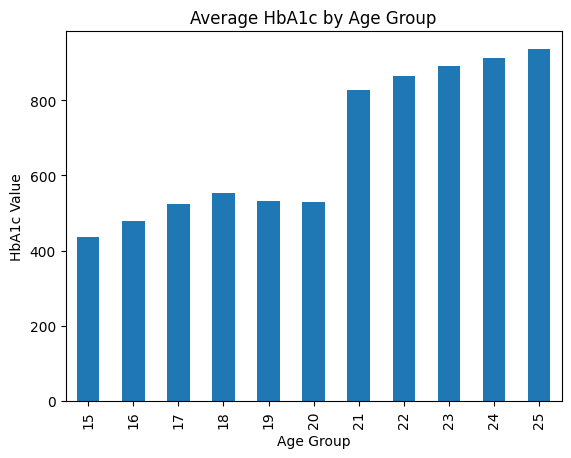

In [15]:
# Step 8: Plot results
df_grouped.plot(kind="bar")
plt.title("Average HbA1c by Age Group")
plt.xlabel("Age Group")
plt.ylabel("HbA1c Value")
plt.show()

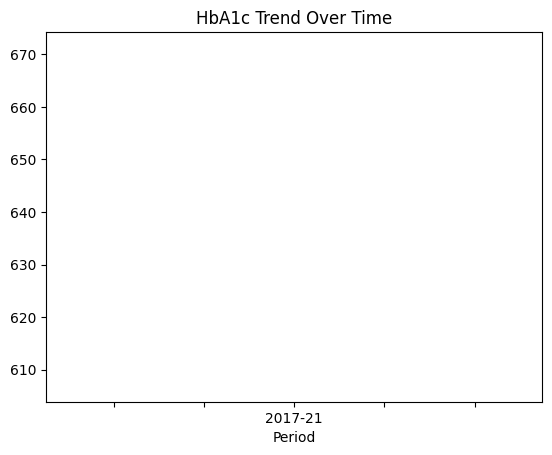

In [17]:
# Step 9: Trend over time
df["Period"] = pd.to_datetime(df["Period"], errors="coerce")

df_time = df_hba1c.groupby("Period")["Value"].mean()
df_time.plot()
plt.title("HbA1c Trend Over Time")
plt.show()